Cat image size (300, 451, 3)
Astronaut image size (512, 512, 3)
Coins image size (303, 384)


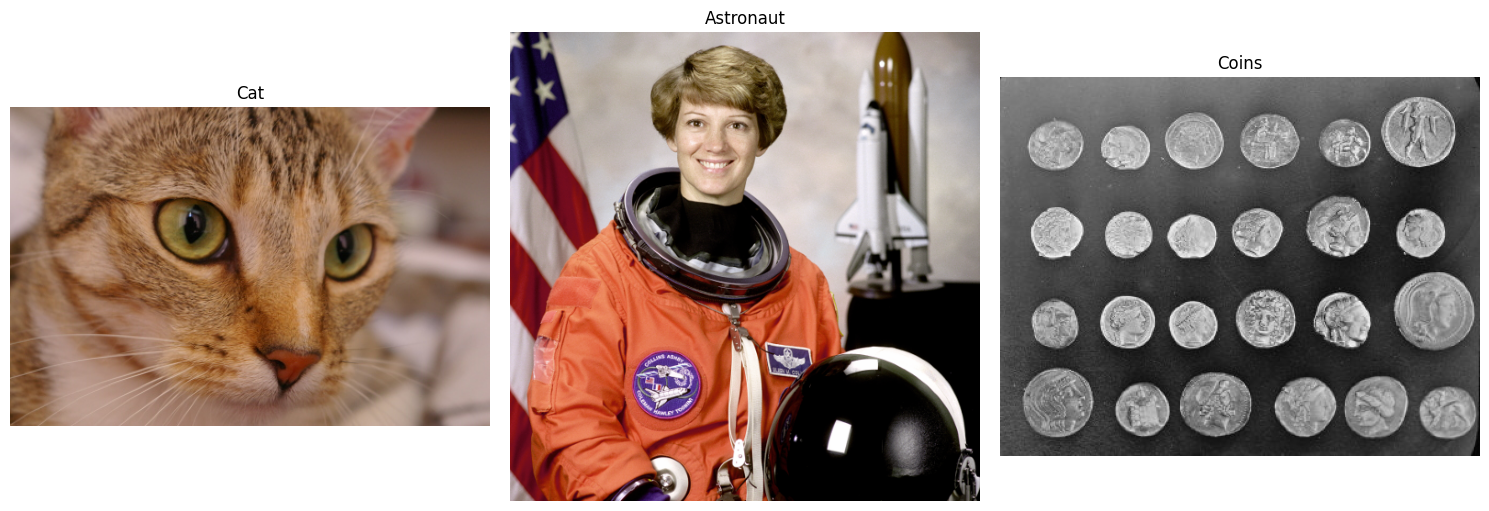

In [1]:
import cv2
from skimage import data
import matplotlib.pyplot as plt

# 1. Load the pre-loaded images from skimage
img_cat = data.cat() 
img_ast = data.astronaut()
img_coins = data.coins()

print("Cat image size",img_cat.shape)
print("Astronaut image size",img_ast.shape)
print("Coins image size",img_coins.shape)

# 2. Setup a grid to display all three results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Display Cat (Color image)
axes[0].imshow(img_cat)
axes[0].set_title('Cat')
axes[0].axis('off')

# Display Astronaut (Color image)
axes[1].imshow(img_ast)
axes[1].set_title('Astronaut')
axes[1].axis('off')

# Display Coins (Grayscale image - needs gray colormap)
axes[2].imshow(img_coins, cmap='gray')
axes[2].set_title('Coins')
axes[2].axis('off')

plt.tight_layout()
plt.show()


## Converting to Grayscale image

| Property | RGB Image | Grayscale Image |
| :--- | :--- | :--- |
| **Channels** | 3 (Red, Green, Blue) | 1 (Intensity / Luminance) |
| **Data Size / Memory** | ~3x larger (typically 24 bits per pixel) | ~3x smaller (typically 8 bits per pixel) |
| **Pixel Value Structure** | Array of triplets: `[R, G, B]` (e.g., `[255, 0, 0]` for red) | Single scalar intensity value |
| **Pixel Value Range** | 0 to 255 for each channel (8-bit depth) | 0 (Black) to 255 (White) |
| **Array Dimensions** | 3D Array ($\text{Height} \times \text{Width} \times 3$) | 2D Array ($\text{Height} \times \text{Width}$) |

Cat image size (300, 451, 3)
Astronaut image size (512, 512, 3)
Coins image size (303, 384)


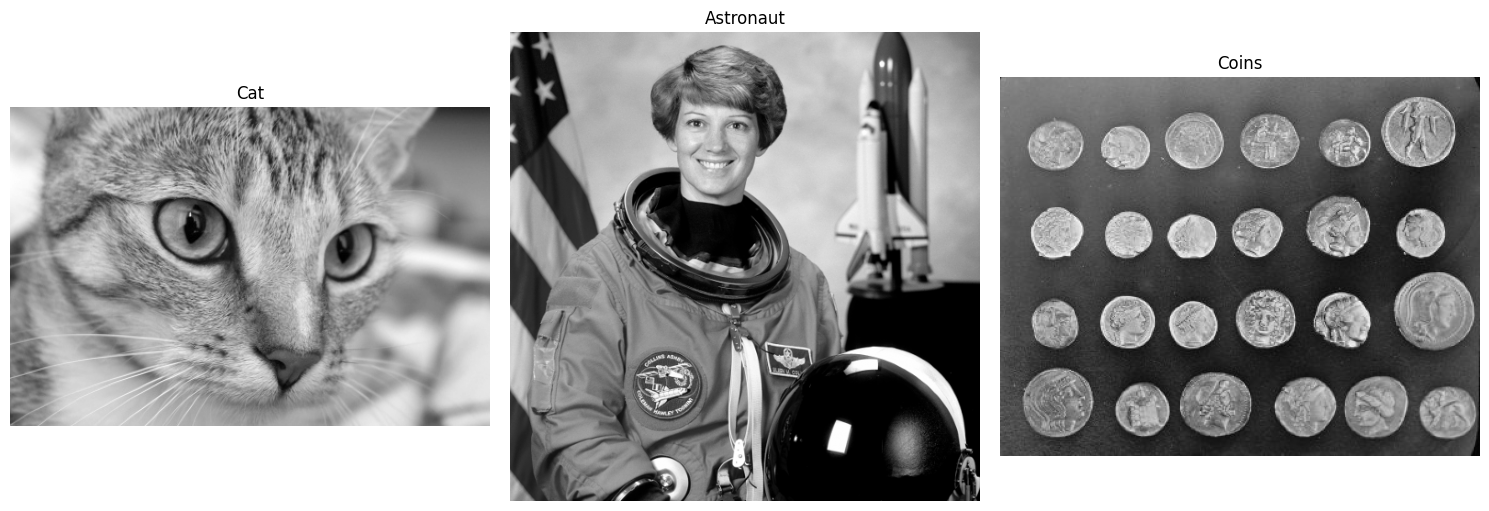

In [3]:
# Note: skimage loads in RGB. If you want to use OpenCV specific functions 
# that expect BGR, convert it:
img_cat_gray = cv2.cvtColor(img_cat, cv2.COLOR_RGB2GRAY)
img_ast_gray = cv2.cvtColor(img_ast, cv2.COLOR_RGB2GRAY)
img_coins_gray = img_coins


print("Cat image size",img_cat.shape)
print("Astronaut image size",img_ast.shape)
print("Coins image size",img_coins.shape)

# 2. Setup a grid to display all three results side-by-side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Display Cat (Color image)
axes[0].imshow(img_cat_gray, cmap='gray')
axes[0].set_title('Cat')
axes[0].axis('off')

# Display Astronaut (Color image)
axes[1].imshow(img_ast_gray, cmap='gray')
axes[1].set_title('Astronaut')
axes[1].axis('off')

# Display Coins (Grayscale image - needs gray colormap)
axes[2].imshow(img_coins_gray, cmap='gray')
axes[2].set_title('Coins')
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Pixel Processing

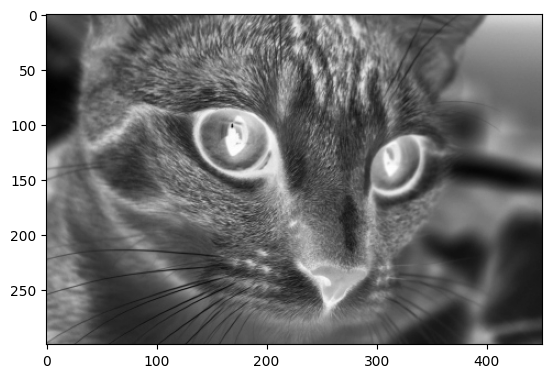

In [6]:
# negative image 
negative = 255 - img_cat_gray

plt.imshow(negative,cmap="gray")

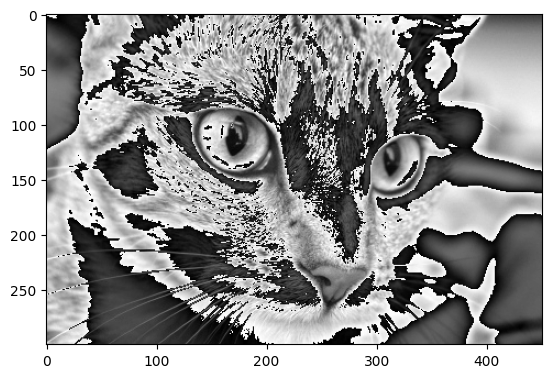

In [7]:
# Increasing Contrast 

Contrast = 2* img_cat_gray

plt.imshow(Contrast,cmap="gray")

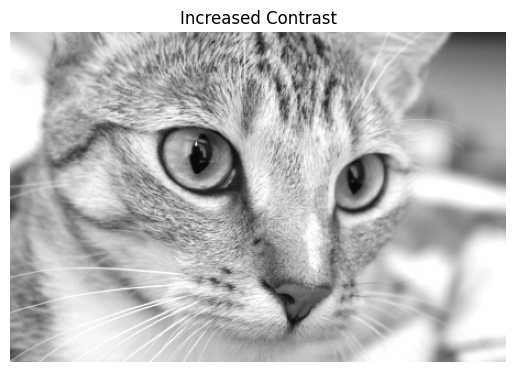

In [9]:
# alpha > 1 increases contrast, beta adds brightness
contrast = cv2.convertScaleAbs(img_cat_gray, alpha=1.5, beta=0)

plt.imshow(contrast, cmap="gray", vmin=0, vmax=255)
plt.title("Increased Contrast")
plt.axis("off")
plt.show()

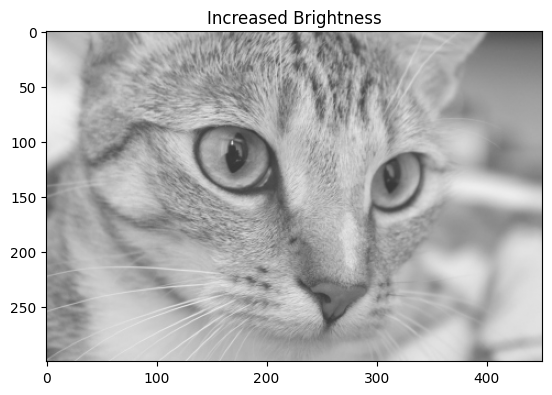

In [8]:
# Option 1: Using cv2.add (Recommended - automatically caps values at 255)
bright = cv2.add(img_cat_gray, 50)  # Increase brightness by 50 units

plt.imshow(bright, cmap="gray", vmin=0, vmax=255)
plt.title("Increased Brightness")
plt.show()

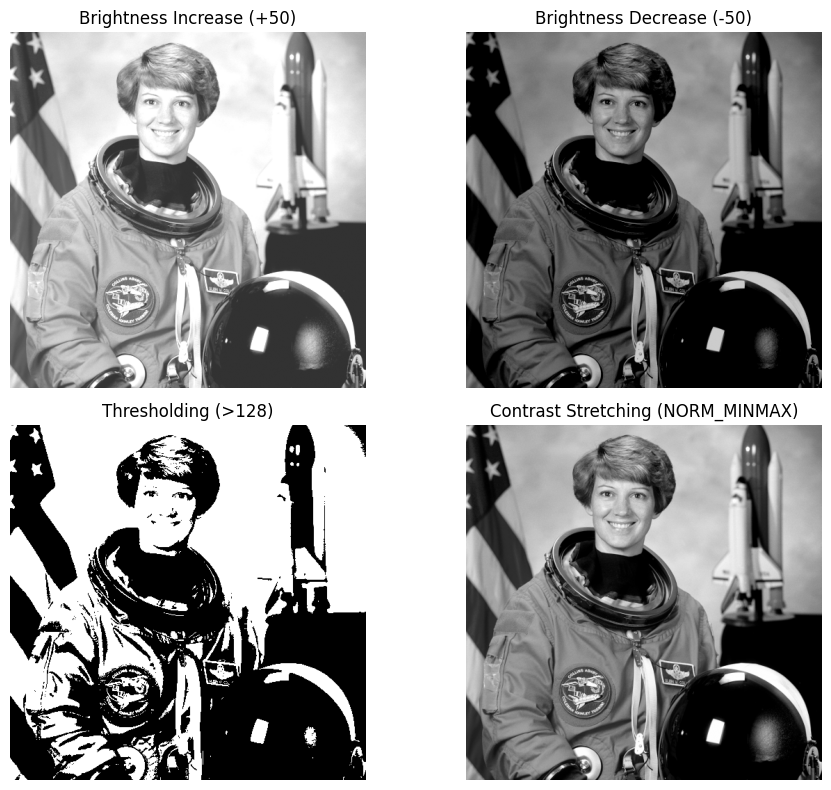

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = img_ast_gray

# 1. Brightness Increase
brightness = np.clip(img.astype(np.int16) + 50, 0, 255).astype(np.uint8)

# 2. Brightness Decrease
dark = np.clip(img.astype(np.int16) - 50, 0, 255).astype(np.uint8)

# 3. Thresholding
threshold = np.where(img > 128, 255, 0).astype(np.uint8)

# 4. Contrast Stretching
contrast = cv2.normalize(
    img,
    None,
    alpha=0,
    beta=255,
    norm_type=cv2.NORM_MINMAX
)

# Plotting the results
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].imshow(brightness, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title('Brightness Increase (+50)')
axes[0, 0].axis('off')

axes[0, 1].imshow(dark, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title('Brightness Decrease (-50)')
axes[0, 1].axis('off')

axes[1, 0].imshow(threshold, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title('Thresholding (>128)')
axes[1, 0].axis('off')

axes[1, 1].imshow(contrast, cmap='gray', vmin=0, vmax=255)
axes[1, 1].set_title('Contrast Stretching (NORM_MINMAX)')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

## Linear Filter

## Non Linear Filter

## Template Matching

## Image Processing In Frequency Domain 

## Deconvolutions

## Sampling Theory and Aliasing